ONTOLOGIAS

In [6]:
!pip install rdflib
!pip install owlrl
!pip install rdflib

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


In [7]:
from rdflib import Graph, RDF, RDFS, Namespace, Literal, XSD
from rdflib.namespace import FOAF, SKOS, DC
from rdflib import Namespace
from rdflib.namespace import RDF, DC, XSD
from rdflib import Graph, RDF, RDFS, Namespace, Literal, URIRef, XSD
from rdflib.namespace import FOAF, SKOS, DC
import owlrl

DCMITYPE = Namespace("http://purl.org/dc/dcmitype/")

# ============================================================
# 0. CREACIÓN DEL GRAFO Y NAMESPACES
# ============================================================
# Exigencia:
# - Implementar la ontología del dominio usando RDF/RDFS.
# - El lenguaje de serialización final será Turtle.
# - Incluir vocabularios aceptados en la literatura: FOAF, Dublin Core, SKOS.

g = Graph()

NS = Namespace("http://unal.edu.co/cripto#")

g.bind("cripto", NS)
g.bind("foaf", FOAF)
g.bind("skos", SKOS)
g.bind("dc", DC)


# ============================================================
# 1. CLASES DE LA ONTOLOGÍA
# ============================================================
# Exigencia:
# - Implementar al menos 10 clases rdfs:Class.
# - Cada clase debe tener rdfs:label explicando su significado.

clases = [
    (
        NS.AlgoritmoCriptografico,
        "Algoritmo criptográfico usado para proteger información mediante cifrado, firma, hash o intercambio de claves."
    ),
    (
        NS.CifradoSimetrico,
        "Algoritmo criptográfico que utiliza una clave compartida para cifrar y descifrar información."
    ),
    (
        NS.CifradoAsimetrico,
        "Algoritmo criptográfico que utiliza un par de claves, generalmente pública y privada."
    ),
    (
        NS.FuncionHash,
        "Algoritmo que produce una huella digital de tamaño fijo a partir de datos de entrada."
    ),
    (
        NS.AlgoritmoPostCuantico,
        "Algoritmo criptográfico diseñado para resistir ataques realizados con computación cuántica."
    ),
    (
        NS.AlgoritmoVulnerable,
        "Algoritmo criptográfico que presenta debilidades conocidas, obsolescencia o inseguridad práctica."
    ),
    (
        NS.ContextoUso,
        "Escenario, entorno o necesidad donde puede aplicarse una solución criptográfica."
    ),
    (
        NS.RecursoLimitado,
        "Contexto de uso con restricciones importantes de memoria, energía o capacidad de procesamiento."
    ),
    (
        NS.InfraestructuraCritica,
        "Contexto de uso donde una falla de seguridad puede afectar servicios esenciales o sistemas de alto impacto."
    ),
    (
        NS.EstadoSeguridad,
        "Categoría que representa el nivel o condición de seguridad de un algoritmo criptográfico."
    )
]

for clase, label in clases:
    g.add((clase, RDF.type, RDFS.Class))
    g.add((clase, RDFS.label, Literal(label, lang="es")))


# ============================================================
# 2. JERARQUÍAS DE CLASES
# ============================================================
# Exigencia:
# - Crear al menos 5 relaciones jerárquicas rdfs:subClassOf.
#
# Corrección importante:
# - AlgoritmoPostCuantico y AlgoritmoVulnerable son tipos de algoritmo,
#   no estados de seguridad.
# - EstadoSeguridad queda como una clase aparte para individuos como
#   AltaSeguridad, Obsoleto, Vulnerable, etc.

jerarquias_clases = [
    (NS.CifradoSimetrico, NS.AlgoritmoCriptografico),
    (NS.CifradoAsimetrico, NS.AlgoritmoCriptografico),
    (NS.FuncionHash, NS.AlgoritmoCriptografico),
    (NS.AlgoritmoPostCuantico, NS.AlgoritmoCriptografico),
    (NS.AlgoritmoVulnerable, NS.AlgoritmoCriptografico),
    (NS.RecursoLimitado, NS.ContextoUso),
    (NS.InfraestructuraCritica, NS.ContextoUso)
]

for subclase, superclase in jerarquias_clases:
    g.add((subclase, RDFS.subClassOf, superclase))


# ============================================================
# 3. PROPIEDADES RDF CON DOMAIN Y RANGE
# ============================================================
# Exigencia:
# - Crear al menos 10 propiedades RDF originales.
# - Cada propiedad debe tener rdfs:domain y rdfs:range correctamente definidos.
# - Cada propiedad debe tener rdfs:label.
# - Incluir rangos de tipo clase URI y rangos literales con XML-Schema.
#
# Correcciones importantes:
# - esVulnerableA ahora tiene rango Literal, porque guarda descripción textual.
# - tieneNivelSeguridad apunta a EstadoSeguridad.
# - esRecomendadoPara va de AlgoritmoCriptografico a ContextoUso.
# - usaAlgoritmoRecomendado va de ContextoUso a AlgoritmoCriptografico.
#   Así no se usa la misma propiedad en dos sentidos distintos.

propiedades = [
    (
        NS.esRecomendadoPara,
        "Relaciona un algoritmo criptográfico con un contexto de uso donde resulta adecuado.",
        NS.AlgoritmoCriptografico,
        NS.ContextoUso
    ),
    (
        NS.usaAlgoritmoRecomendado,
        "Relaciona un contexto de uso con un algoritmo recomendado para ese escenario.",
        NS.ContextoUso,
        NS.AlgoritmoCriptografico
    ),
    (
        NS.tieneNivelSeguridad,
        "Relaciona un algoritmo criptográfico con su estado o nivel de seguridad.",
        NS.AlgoritmoCriptografico,
        NS.EstadoSeguridad
    ),
    (
        NS.requiereNivelSeguridad,
        "Indica el nivel de seguridad requerido por un contexto de uso.",
        NS.ContextoUso,
        NS.EstadoSeguridad
    ),
    (
        NS.esVulnerableA,
        "Describe una vulnerabilidad real o debilidad conocida de un algoritmo.",
        NS.AlgoritmoCriptografico,
        RDFS.Literal
    ),
    (
        NS.tieneRiesgoCondicional,
        "Describe un riesgo que aparece solo si el algoritmo se implementa o usa incorrectamente.",
        NS.AlgoritmoCriptografico,
        RDFS.Literal
    ),
    (
        NS.tieneFortalezaSeguridad,
        "Describe una fortaleza de seguridad relevante del algoritmo.",
        NS.AlgoritmoCriptografico,
        RDFS.Literal
    ),
    (
        NS.utilizaClaveDeTamano,
        "Indica el tamaño de clave utilizado o recomendado por un algoritmo, en bits.",
        NS.AlgoritmoCriptografico,
        XSD.integer
    ),
    (
        NS.tieneTamanoSalidaBits,
        "Indica el tamaño de salida en bits para funciones hash o firmas.",
        NS.AlgoritmoCriptografico,
        XSD.integer
    ),
    (
        NS.requiereTamanoClaveMinimo,
        "Indica el tamaño mínimo de clave requerido por un contexto de uso, en bits.",
        NS.ContextoUso,
        XSD.integer
    ),
    (
        NS.fueEstandarizadoPor,
        "Indica la organización, entidad o estándar asociado al algoritmo.",
        NS.AlgoritmoCriptografico,
        XSD.string
    ),
    (
        NS.tieneVelocidadEjecucion,
        "Indica una categoría cualitativa de velocidad de ejecución: Alta, Media o Baja.",
        NS.AlgoritmoCriptografico,
        XSD.string
    ),
    (
        NS.requiereMemoria,
        "Indica una categoría cualitativa de uso de memoria: Alta, Media o Baja.",
        NS.AlgoritmoCriptografico,
        XSD.string
    ),
    (
        NS.añoDeCreacion,
        "Indica el año de creación, publicación o estandarización del algoritmo.",
        NS.AlgoritmoCriptografico,
        XSD.gYear
    ),
    (
        NS.tieneLimitacionGeneral,
        "Describe una limitación general del algoritmo o contexto.",
        RDFS.Resource,
        RDFS.Literal
    ),
    (
        NS.tieneLimitacionTecnica,
        "Describe una limitación técnica específica del algoritmo o contexto.",
        RDFS.Resource,
        RDFS.Literal
    )
]

for prop, label, dominio, rango in propiedades:
    g.add((prop, RDF.type, RDF.Property))
    g.add((prop, RDFS.label, Literal(label, lang="es")))
    g.add((prop, RDFS.domain, dominio))
    g.add((prop, RDFS.range, rango))


# ============================================================
# 4. JERARQUÍA DE PROPIEDADES
# ============================================================
# Exigencia:
# - Incluir al menos un caso de rdfs:subPropertyOf.
# - Incluir propiedades provenientes de vocabularios aceptados.
#
# Caso 1:
# - Toda limitación técnica también es una limitación general.
#
# Caso 2:
# - fueEstandarizadoPor se relaciona con Dublin Core publisher.
#   Esto permite mostrar uso de vocabulario externo aceptado.

g.add((NS.tieneLimitacionTecnica, RDFS.subPropertyOf, NS.tieneLimitacionGeneral))
g.add((NS.fueEstandarizadoPor, RDFS.subPropertyOf, DC.publisher))


# ============================================================
# 5. INDIVIDUOS DE ESTADO DE SEGURIDAD
# ============================================================
# Exigencia:
# - Instanciar individuos por clase.
#
# Corrección:
# - AltaSeguridad, SeguridadMedia, BajaSeguridad, Obsoleto y Vulnerable
#   son individuos de EstadoSeguridad.
# - No se mezclan con clases como AlgoritmoVulnerable.

estados_seguridad = [
    (NS.AltaSeguridad, "Alta seguridad"),
    (NS.SeguridadMedia, "Seguridad media"),
    (NS.BajaSeguridad, "Baja seguridad"),
    (NS.Obsoleto, "Obsoleto"),
    (NS.Vulnerable, "Vulnerable"),
    (NS.PostCuanticoSeguro, "Seguro frente a amenazas cuánticas conocidas")
]

for estado, label in estados_seguridad:
    g.add((estado, RDF.type, NS.EstadoSeguridad))
    g.add((estado, RDFS.label, Literal(label, lang="es")))


# ============================================================
# 6. INDIVIDUOS DE CONTEXTO DE USO
# ============================================================
# Exigencia:
# - Instanciar individuos.
# - Usar rangos de tipo clase URI.
#
# Corrección:
# - BancaEnLinea, FirmaDigital, Blockchain, etc. ahora sí son individuos
#   explícitos de ContextoUso.
# - Antes se usaban como URIs sueltas sin declararlas formalmente.

contextos_generales = [
    (NS.BancaEnLinea, "Banca en línea"),
    (NS.SistemasHeredados, "Sistemas heredados"),
    (NS.DispositivosMoviles, "Dispositivos móviles"),
    (NS.FirmaDigital, "Firma digital"),
    (NS.AlmacenamientoLargoPlazo, "Almacenamiento a largo plazo"),
    (NS.Blockchain, "Blockchain"),
    (NS.TransmisionTiempoReal, "Transmisión en tiempo real"),
    (NS.AutenticacionUsuarios, "Autenticación de usuarios"),
    (NS.DispositivosIoT, "Dispositivos IoT")
]

for contexto, label in contextos_generales:
    g.add((contexto, RDF.type, NS.ContextoUso))
    g.add((contexto, RDFS.label, Literal(label, lang="es")))


# ============================================================
# 7. INDIVIDUOS DE CIFRADO SIMÉTRICO
# ============================================================
# Exigencia:
# - Instanciar al menos 4 individuos por clase.
#
# Aquí hay 4 individuos de CifradoSimetrico:
# - AES_256
# - DES
# - TDES
# - ChaCha20
#
# Corrección:
# - Las vulnerabilidades reales se dejan en esVulnerableA.
# - Los riesgos por mal uso o mala implementación van en tieneRiesgoCondicional.
# - Las fortalezas van en tieneFortalezaSeguridad.

# AES-256
g.add((NS.AES_256, RDF.type, NS.CifradoSimetrico))
g.add((NS.AES_256, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.AES_256, RDFS.label, Literal("AES con clave de 256 bits", lang="es")))
g.add((NS.AES_256, SKOS.prefLabel, Literal("AES-256", lang="es")))
g.add((NS.AES_256, NS.esRecomendadoPara, NS.BancaEnLinea))
g.add((NS.AES_256, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.AES_256, NS.tieneRiesgoCondicional, Literal("Puede sufrir ataques de canal lateral si se implementa incorrectamente.", lang="es")))
g.add((NS.AES_256, NS.tieneFortalezaSeguridad, Literal("Cifrado simétrico ampliamente usado y estandarizado para alta seguridad.", lang="es")))
g.add((NS.AES_256, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.AES_256, NS.fueEstandarizadoPor, Literal("NIST", datatype=XSD.string)))
g.add((NS.AES_256, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.AES_256, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.AES_256, NS.añoDeCreacion, Literal("1998", datatype=XSD.gYear)))
g.add((NS.AES_256, NS.tieneLimitacionTecnica, Literal("Puede requerir AES-NI para máximo rendimiento.", lang="es")))

# DES
g.add((NS.DES, RDF.type, NS.CifradoSimetrico))
g.add((NS.DES, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.DES, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.DES, RDFS.label, Literal("DES - Estándar de Cifrado de Datos", lang="es")))
g.add((NS.DES, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.DES, NS.tieneNivelSeguridad, NS.Vulnerable))
g.add((NS.DES, NS.esVulnerableA, Literal("Ataque de fuerza bruta por espacio de claves reducido.", lang="es")))
g.add((NS.DES, NS.utilizaClaveDeTamano, Literal(56, datatype=XSD.integer)))
g.add((NS.DES, NS.fueEstandarizadoPor, Literal("NBS / NIST", datatype=XSD.string)))
g.add((NS.DES, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.DES, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.DES, NS.añoDeCreacion, Literal("1977", datatype=XSD.gYear)))
g.add((NS.DES, NS.tieneLimitacionGeneral, Literal("No debe usarse para proteger información sensible actual.", lang="es")))
g.add((NS.DES, NS.tieneLimitacionTecnica, Literal("Clave de 56 bits insuficiente para hardware moderno.", lang="es")))

# Triple DES
g.add((NS.TDES, RDF.type, NS.CifradoSimetrico))
g.add((NS.TDES, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.TDES, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.TDES, RDFS.label, Literal("Triple DES", lang="es")))
g.add((NS.TDES, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.TDES, NS.tieneNivelSeguridad, NS.Obsoleto))
g.add((NS.TDES, NS.esVulnerableA, Literal("Tamaño de bloque pequeño y riesgo en grandes volúmenes de datos.", lang="es")))
g.add((NS.TDES, NS.utilizaClaveDeTamano, Literal(168, datatype=XSD.integer)))
g.add((NS.TDES, NS.fueEstandarizadoPor, Literal("NIST", datatype=XSD.string)))
g.add((NS.TDES, NS.tieneVelocidadEjecucion, Literal("Baja", datatype=XSD.string)))
g.add((NS.TDES, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.TDES, NS.añoDeCreacion, Literal("1998", datatype=XSD.gYear)))
g.add((NS.TDES, NS.tieneLimitacionGeneral, Literal("Algoritmo heredado y menos eficiente que AES.", lang="es")))
g.add((NS.TDES, NS.tieneLimitacionTecnica, Literal("Tamaño de bloque de 64 bits.", lang="es")))

# ChaCha20
g.add((NS.ChaCha20, RDF.type, NS.CifradoSimetrico))
g.add((NS.ChaCha20, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.ChaCha20, RDFS.label, Literal("ChaCha20", lang="es")))
g.add((NS.ChaCha20, NS.esRecomendadoPara, NS.DispositivosMoviles))
g.add((NS.ChaCha20, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.ChaCha20, NS.tieneRiesgoCondicional, Literal("La reutilización del nonce compromete la seguridad.", lang="es")))
g.add((NS.ChaCha20, NS.tieneFortalezaSeguridad, Literal("Buen rendimiento en dispositivos sin aceleración AES.", lang="es")))
g.add((NS.ChaCha20, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.ChaCha20, NS.fueEstandarizadoPor, Literal("IETF", datatype=XSD.string)))
g.add((NS.ChaCha20, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.ChaCha20, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.ChaCha20, NS.añoDeCreacion, Literal("2008", datatype=XSD.gYear)))
g.add((NS.ChaCha20, NS.tieneLimitacionTecnica, Literal("Requiere manejo correcto de nonces.", lang="es")))


# ============================================================
# 8. INDIVIDUOS DE CIFRADO ASIMÉTRICO
# ============================================================
# Exigencia:
# - 4 individuos para CifradoAsimetrico.
#
# Aquí:
# - RSA_2048
# - RSA_4096
# - ECC_256
# - DiffieHellman

# RSA 2048
g.add((NS.RSA_2048, RDF.type, NS.CifradoAsimetrico))
g.add((NS.RSA_2048, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.RSA_2048, RDFS.label, Literal("RSA con clave de 2048 bits", lang="es")))
g.add((NS.RSA_2048, NS.esRecomendadoPara, NS.FirmaDigital))
g.add((NS.RSA_2048, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.RSA_2048, NS.tieneRiesgoCondicional, Literal("Es vulnerable a computación cuántica de gran escala mediante Shor.", lang="es")))
g.add((NS.RSA_2048, NS.utilizaClaveDeTamano, Literal(2048, datatype=XSD.integer)))
g.add((NS.RSA_2048, NS.fueEstandarizadoPor, Literal("RSA Laboratories / IETF", datatype=XSD.string)))
g.add((NS.RSA_2048, NS.tieneVelocidadEjecucion, Literal("Baja", datatype=XSD.string)))
g.add((NS.RSA_2048, NS.requiereMemoria, Literal("Media", datatype=XSD.string)))
g.add((NS.RSA_2048, NS.añoDeCreacion, Literal("1977", datatype=XSD.gYear)))
g.add((NS.RSA_2048, NS.tieneLimitacionGeneral, Literal("Lento frente al cifrado simétrico.", lang="es")))

# RSA 4096
g.add((NS.RSA_4096, RDF.type, NS.CifradoAsimetrico))
g.add((NS.RSA_4096, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.RSA_4096, RDFS.label, Literal("RSA con clave de 4096 bits", lang="es")))
g.add((NS.RSA_4096, NS.esRecomendadoPara, NS.AlmacenamientoLargoPlazo))
g.add((NS.RSA_4096, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.RSA_4096, NS.tieneRiesgoCondicional, Literal("No es post-cuántico; vulnerable ante computadores cuánticos suficientemente grandes.", lang="es")))
g.add((NS.RSA_4096, NS.utilizaClaveDeTamano, Literal(4096, datatype=XSD.integer)))
g.add((NS.RSA_4096, NS.fueEstandarizadoPor, Literal("NIST / BSI", datatype=XSD.string)))
g.add((NS.RSA_4096, NS.tieneVelocidadEjecucion, Literal("Baja", datatype=XSD.string)))
g.add((NS.RSA_4096, NS.requiereMemoria, Literal("Alta", datatype=XSD.string)))
g.add((NS.RSA_4096, NS.añoDeCreacion, Literal("2002", datatype=XSD.gYear)))
g.add((NS.RSA_4096, NS.tieneLimitacionTecnica, Literal("Descifrado y firma más costosos que RSA-2048.", lang="es")))

# ECC 256
g.add((NS.ECC_256, RDF.type, NS.CifradoAsimetrico))
g.add((NS.ECC_256, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.ECC_256, RDFS.label, Literal("Criptografía de Curva Elíptica de 256 bits", lang="es")))
g.add((NS.ECC_256, NS.esRecomendadoPara, NS.Blockchain))
g.add((NS.ECC_256, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.ECC_256, NS.tieneRiesgoCondicional, Literal("Puede sufrir ataques de canal lateral si la implementación no está protegida.", lang="es")))
g.add((NS.ECC_256, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.ECC_256, NS.fueEstandarizadoPor, Literal("NIST / SECG", datatype=XSD.string)))
g.add((NS.ECC_256, NS.tieneVelocidadEjecucion, Literal("Media", datatype=XSD.string)))
g.add((NS.ECC_256, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.ECC_256, NS.añoDeCreacion, Literal("1985", datatype=XSD.gYear)))
g.add((NS.ECC_256, NS.tieneLimitacionTecnica, Literal("La seguridad depende de la curva elegida.", lang="es")))

# Diffie-Hellman
g.add((NS.DiffieHellman, RDF.type, NS.CifradoAsimetrico))
g.add((NS.DiffieHellman, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.DiffieHellman, RDFS.label, Literal("Diffie-Hellman", lang="es")))
g.add((NS.DiffieHellman, NS.esRecomendadoPara, NS.TransmisionTiempoReal))
g.add((NS.DiffieHellman, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.DiffieHellman, NS.tieneRiesgoCondicional, Literal("Vulnerable a MitM si no se autentica el intercambio.", lang="es")))
g.add((NS.DiffieHellman, NS.utilizaClaveDeTamano, Literal(2048, datatype=XSD.integer)))
g.add((NS.DiffieHellman, NS.fueEstandarizadoPor, Literal("IETF", datatype=XSD.string)))
g.add((NS.DiffieHellman, NS.tieneVelocidadEjecucion, Literal("Baja", datatype=XSD.string)))
g.add((NS.DiffieHellman, NS.requiereMemoria, Literal("Media", datatype=XSD.string)))
g.add((NS.DiffieHellman, NS.añoDeCreacion, Literal("1976", datatype=XSD.gYear)))
g.add((NS.DiffieHellman, NS.tieneLimitacionGeneral, Literal("No cifra mensajes directamente; sirve para intercambio de claves.", lang="es")))


# ============================================================
# 9. INDIVIDUOS DE FUNCIÓN HASH
# ============================================================
# Exigencia:
# - 4 individuos para FuncionHash.
#
# Corrección:
# - Para funciones hash no se usa utilizaClaveDeTamano como si fuera clave.
# - Se usa tieneTamanoSalidaBits.

# SHA-256
g.add((NS.SHA_256, RDF.type, NS.FuncionHash))
g.add((NS.SHA_256, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.SHA_256, RDFS.label, Literal("SHA-256", lang="es")))
g.add((NS.SHA_256, NS.esRecomendadoPara, NS.AutenticacionUsuarios))
g.add((NS.SHA_256, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SHA_256, NS.tieneRiesgoCondicional, Literal("Puede sufrir ataques de extensión de longitud si se usa incorrectamente.", lang="es")))
g.add((NS.SHA_256, NS.tieneTamanoSalidaBits, Literal(256, datatype=XSD.integer)))
g.add((NS.SHA_256, NS.fueEstandarizadoPor, Literal("NIST", datatype=XSD.string)))
g.add((NS.SHA_256, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.SHA_256, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.SHA_256, NS.añoDeCreacion, Literal("2001", datatype=XSD.gYear)))
g.add((NS.SHA_256, NS.tieneLimitacionTecnica, Literal("Diseño basado en Merkle-Damgård.", lang="es")))

# SHA-1
g.add((NS.SHA_1, RDF.type, NS.FuncionHash))
g.add((NS.SHA_1, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.SHA_1, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.SHA_1, RDFS.label, Literal("SHA-1", lang="es")))
g.add((NS.SHA_1, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.SHA_1, NS.tieneNivelSeguridad, NS.Vulnerable))
g.add((NS.SHA_1, NS.esVulnerableA, Literal("Ataques de colisión prácticos.", lang="es")))
g.add((NS.SHA_1, NS.tieneTamanoSalidaBits, Literal(160, datatype=XSD.integer)))
g.add((NS.SHA_1, NS.fueEstandarizadoPor, Literal("NIST", datatype=XSD.string)))
g.add((NS.SHA_1, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.SHA_1, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.SHA_1, NS.añoDeCreacion, Literal("1995", datatype=XSD.gYear)))
g.add((NS.SHA_1, NS.tieneLimitacionGeneral, Literal("No se recomienda para firmas digitales modernas.", lang="es")))

# MD5
g.add((NS.MD5, RDF.type, NS.FuncionHash))
g.add((NS.MD5, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.MD5, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.MD5, RDFS.label, Literal("MD5", lang="es")))
g.add((NS.MD5, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.MD5, NS.tieneNivelSeguridad, NS.Vulnerable))
g.add((NS.MD5, NS.esVulnerableA, Literal("Colisiones criptográficas prácticas.", lang="es")))
g.add((NS.MD5, NS.tieneTamanoSalidaBits, Literal(128, datatype=XSD.integer)))
g.add((NS.MD5, NS.fueEstandarizadoPor, Literal("IETF", datatype=XSD.string)))
g.add((NS.MD5, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.MD5, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.MD5, NS.añoDeCreacion, Literal("1991", datatype=XSD.gYear)))
g.add((NS.MD5, NS.tieneLimitacionGeneral, Literal("Criptográficamente roto para seguridad moderna.", lang="es")))

# SHA-3
g.add((NS.SHA_3, RDF.type, NS.FuncionHash))
g.add((NS.SHA_3, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.SHA_3, RDFS.label, Literal("SHA-3", lang="es")))
g.add((NS.SHA_3, NS.esRecomendadoPara, NS.Blockchain))
g.add((NS.SHA_3, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SHA_3, NS.tieneFortalezaSeguridad, Literal("Diseño de esponja resistente a ataques conocidos contra SHA-2.", lang="es")))
g.add((NS.SHA_3, NS.tieneTamanoSalidaBits, Literal(512, datatype=XSD.integer)))
g.add((NS.SHA_3, NS.fueEstandarizadoPor, Literal("NIST", datatype=XSD.string)))
g.add((NS.SHA_3, NS.tieneVelocidadEjecucion, Literal("Media", datatype=XSD.string)))
g.add((NS.SHA_3, NS.requiereMemoria, Literal("Media", datatype=XSD.string)))
g.add((NS.SHA_3, NS.añoDeCreacion, Literal("2015", datatype=XSD.gYear)))
g.add((NS.SHA_3, NS.tieneLimitacionTecnica, Literal("Puede ser más lento que SHA-2 en algunos entornos.", lang="es")))


# ============================================================
# 10. INDIVIDUOS DE ALGORITMO POST-CUÁNTICO
# ============================================================
# Exigencia:
# - 4 individuos para AlgoritmoPostCuantico.
#
# Aquí:
# - Kyber
# - Dilithium
# - SphincsPlus
# - Falcon

# Kyber
g.add((NS.Kyber, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.Kyber, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.Kyber, RDFS.label, Literal("CRYSTALS-Kyber", lang="es")))
g.add((NS.Kyber, NS.esRecomendadoPara, NS.InfraestructuraCritica))
g.add((NS.Kyber, NS.tieneNivelSeguridad, NS.PostCuanticoSeguro))
g.add((NS.Kyber, NS.tieneRiesgoCondicional, Literal("Puede sufrir ataques de canal lateral en implementaciones físicas.", lang="es")))
g.add((NS.Kyber, NS.tieneFortalezaSeguridad, Literal("Diseñado para intercambio de claves resistente a amenazas cuánticas.", lang="es")))
g.add((NS.Kyber, NS.utilizaClaveDeTamano, Literal(1632, datatype=XSD.integer)))
g.add((NS.Kyber, NS.fueEstandarizadoPor, Literal("NIST FIPS 203", datatype=XSD.string)))
g.add((NS.Kyber, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.Kyber, NS.requiereMemoria, Literal("Media", datatype=XSD.string)))
g.add((NS.Kyber, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.Kyber, NS.tieneLimitacionTecnica, Literal("Basado en problemas de redes/lattices.", lang="es")))

# Dilithium
g.add((NS.Dilithium, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.Dilithium, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.Dilithium, RDFS.label, Literal("CRYSTALS-Dilithium", lang="es")))
g.add((NS.Dilithium, NS.esRecomendadoPara, NS.FirmaDigital))
g.add((NS.Dilithium, NS.tieneNivelSeguridad, NS.PostCuanticoSeguro))
g.add((NS.Dilithium, NS.tieneFortalezaSeguridad, Literal("Firma digital resistente a ataques cuánticos conocidos.", lang="es")))
g.add((NS.Dilithium, NS.utilizaClaveDeTamano, Literal(2592, datatype=XSD.integer)))
g.add((NS.Dilithium, NS.fueEstandarizadoPor, Literal("NIST FIPS 204", datatype=XSD.string)))
g.add((NS.Dilithium, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.Dilithium, NS.requiereMemoria, Literal("Media", datatype=XSD.string)))
g.add((NS.Dilithium, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.Dilithium, NS.tieneLimitacionTecnica, Literal("Firmas más grandes que ECDSA o RSA.", lang="es")))

# SPHINCS+
g.add((NS.SphincsPlus, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.SphincsPlus, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.SphincsPlus, RDFS.label, Literal("SPHINCS+", lang="es")))
g.add((NS.SphincsPlus, NS.esRecomendadoPara, NS.AlmacenamientoLargoPlazo))
g.add((NS.SphincsPlus, NS.tieneNivelSeguridad, NS.PostCuanticoSeguro))
g.add((NS.SphincsPlus, NS.tieneFortalezaSeguridad, Literal("Firma basada en hash, útil como alternativa conservadora a largo plazo.", lang="es")))
g.add((NS.SphincsPlus, NS.utilizaClaveDeTamano, Literal(32, datatype=XSD.integer)))
g.add((NS.SphincsPlus, NS.fueEstandarizadoPor, Literal("NIST FIPS 205", datatype=XSD.string)))
g.add((NS.SphincsPlus, NS.tieneVelocidadEjecucion, Literal("Baja", datatype=XSD.string)))
g.add((NS.SphincsPlus, NS.requiereMemoria, Literal("Alta", datatype=XSD.string)))
g.add((NS.SphincsPlus, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.SphincsPlus, NS.tieneLimitacionTecnica, Literal("Generación de firma computacionalmente costosa.", lang="es")))

# Falcon
g.add((NS.Falcon, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.Falcon, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.Falcon, RDFS.label, Literal("Falcon", lang="es")))
g.add((NS.Falcon, NS.esRecomendadoPara, NS.DispositivosIoT))
g.add((NS.Falcon, NS.tieneNivelSeguridad, NS.PostCuanticoSeguro))
g.add((NS.Falcon, NS.tieneRiesgoCondicional, Literal("Implementación compleja por uso de aritmética de punto flotante.", lang="es")))
g.add((NS.Falcon, NS.tieneFortalezaSeguridad, Literal("Firmas compactas útiles cuando el ancho de banda es limitado.", lang="es")))
g.add((NS.Falcon, NS.utilizaClaveDeTamano, Literal(897, datatype=XSD.integer)))
g.add((NS.Falcon, NS.fueEstandarizadoPor, Literal("NIST", datatype=XSD.string)))
g.add((NS.Falcon, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.Falcon, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.Falcon, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.Falcon, NS.tieneLimitacionTecnica, Literal("Difícil de implementar correctamente en hardware limitado.", lang="es")))


# ============================================================
# 11. INDIVIDUOS DE RECURSO LIMITADO
# ============================================================
# Exigencia:
# - 4 individuos para RecursoLimitado.
#
# Corrección:
# - Estos individuos son contextos/dispositivos.
# - No se les aplican propiedades exclusivas de algoritmo como
#   utilizaClaveDeTamano.
# - En su lugar se usan requiereTamanoClaveMinimo, requiereNivelSeguridad
#   y usaAlgoritmoRecomendado.

# Sensor IoT
g.add((NS.SensorIoT_Temp, RDF.type, NS.RecursoLimitado))
g.add((NS.SensorIoT_Temp, RDFS.label, Literal("Sensor IoT de temperatura", lang="es")))
g.add((NS.SensorIoT_Temp, NS.usaAlgoritmoRecomendado, NS.ChaCha20))
g.add((NS.SensorIoT_Temp, NS.requiereNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SensorIoT_Temp, NS.requiereTamanoClaveMinimo, Literal(128, datatype=XSD.integer)))
g.add((NS.SensorIoT_Temp, NS.tieneLimitacionTecnica, Literal("Batería limitada y CPU de baja potencia.", lang="es")))
g.add((NS.SensorIoT_Temp, NS.tieneLimitacionGeneral, Literal("No soporta algoritmos asimétricos pesados.", lang="es")))

# SmartCard
g.add((NS.SmartCard_NFC, RDF.type, NS.RecursoLimitado))
g.add((NS.SmartCard_NFC, RDFS.label, Literal("Tarjeta inteligente NFC", lang="es")))
g.add((NS.SmartCard_NFC, NS.usaAlgoritmoRecomendado, NS.ECC_256))
g.add((NS.SmartCard_NFC, NS.requiereNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SmartCard_NFC, NS.requiereTamanoClaveMinimo, Literal(128, datatype=XSD.integer)))
g.add((NS.SmartCard_NFC, NS.tieneLimitacionTecnica, Literal("Memoria EEPROM reducida.", lang="es")))
g.add((NS.SmartCard_NFC, NS.tieneLimitacionGeneral, Literal("Exposición a ataques físicos y de canal lateral.", lang="es")))

# Marcapasos conectado
g.add((NS.Marcapasos_Conectado, RDF.type, NS.RecursoLimitado))
g.add((NS.Marcapasos_Conectado, RDFS.label, Literal("Marcapasos conectado", lang="es")))
g.add((NS.Marcapasos_Conectado, NS.usaAlgoritmoRecomendado, NS.AES_256))
g.add((NS.Marcapasos_Conectado, NS.requiereNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Marcapasos_Conectado, NS.requiereTamanoClaveMinimo, Literal(128, datatype=XSD.integer)))
g.add((NS.Marcapasos_Conectado, NS.tieneLimitacionTecnica, Literal("Ciclos de CPU limitados para evitar consumo excesivo.", lang="es")))
g.add((NS.Marcapasos_Conectado, NS.tieneLimitacionGeneral, Literal("La duración de la batería es crítica.", lang="es")))

# Router heredado
g.add((NS.Router_Legacy, RDF.type, NS.RecursoLimitado))
g.add((NS.Router_Legacy, RDFS.label, Literal("Router doméstico antiguo", lang="es")))
g.add((NS.Router_Legacy, NS.usaAlgoritmoRecomendado, NS.ChaCha20))
g.add((NS.Router_Legacy, NS.requiereNivelSeguridad, NS.SeguridadMedia))
g.add((NS.Router_Legacy, NS.requiereTamanoClaveMinimo, Literal(128, datatype=XSD.integer)))
g.add((NS.Router_Legacy, NS.tieneLimitacionTecnica, Literal("Memoria RAM y CPU limitadas.", lang="es")))
g.add((NS.Router_Legacy, NS.tieneLimitacionGeneral, Literal("Dificultad para soportar protocolos modernos.", lang="es")))


# ============================================================
# 12. INDIVIDUOS DE INFRAESTRUCTURA CRÍTICA
# ============================================================
# Exigencia:
# - 4 individuos para InfraestructuraCritica.

# Central eléctrica
g.add((NS.Central_Electrica, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Central_Electrica, RDFS.label, Literal("Central eléctrica inteligente", lang="es")))
g.add((NS.Central_Electrica, NS.usaAlgoritmoRecomendado, NS.AES_256))
g.add((NS.Central_Electrica, NS.requiereNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Central_Electrica, NS.requiereTamanoClaveMinimo, Literal(256, datatype=XSD.integer)))
g.add((NS.Central_Electrica, NS.tieneLimitacionTecnica, Literal("Requiere baja latencia para control industrial.", lang="es")))
g.add((NS.Central_Electrica, NS.tieneLimitacionGeneral, Literal("Impacto alto sobre servicios esenciales.", lang="es")))

# Planta de agua
g.add((NS.Planta_Agua, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Planta_Agua, RDFS.label, Literal("Planta de tratamiento de agua", lang="es")))
g.add((NS.Planta_Agua, NS.usaAlgoritmoRecomendado, NS.RSA_4096))
g.add((NS.Planta_Agua, NS.requiereNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Planta_Agua, NS.requiereTamanoClaveMinimo, Literal(256, datatype=XSD.integer)))
g.add((NS.Planta_Agua, NS.tieneLimitacionTecnica, Literal("Hardware industrial con ciclos de vida largos.", lang="es")))
g.add((NS.Planta_Agua, NS.tieneLimitacionGeneral, Literal("Difícil actualización de algoritmos en sitio.", lang="es")))

# Satélite gubernamental
g.add((NS.Satelite_Gob, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Satelite_Gob, RDFS.label, Literal("Satélite de comunicaciones gubernamental", lang="es")))
g.add((NS.Satelite_Gob, NS.usaAlgoritmoRecomendado, NS.Kyber))
g.add((NS.Satelite_Gob, NS.requiereNivelSeguridad, NS.PostCuanticoSeguro))
g.add((NS.Satelite_Gob, NS.requiereTamanoClaveMinimo, Literal(256, datatype=XSD.integer)))
g.add((NS.Satelite_Gob, NS.tieneLimitacionTecnica, Literal("No puede intervenirse físicamente luego del lanzamiento.", lang="es")))
g.add((NS.Satelite_Gob, NS.tieneLimitacionGeneral, Literal("Requiere protección de largo plazo frente a amenazas futuras.", lang="es")))

# Control ferroviario
g.add((NS.Control_Ferroviario, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Control_Ferroviario, RDFS.label, Literal("Sistema de control ferroviario", lang="es")))
g.add((NS.Control_Ferroviario, NS.usaAlgoritmoRecomendado, NS.SHA_3))
g.add((NS.Control_Ferroviario, NS.requiereNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Control_Ferroviario, NS.requiereTamanoClaveMinimo, Literal(256, datatype=XSD.integer)))
g.add((NS.Control_Ferroviario, NS.tieneLimitacionTecnica, Literal("Debe coexistir con protocolos industriales heredados.", lang="es")))
g.add((NS.Control_Ferroviario, NS.tieneLimitacionGeneral, Literal("Fallas de integridad pueden causar accidentes graves.", lang="es")))


# ============================================================
# 13. INDIVIDUOS EXTRA DE ALGORITMO VULNERABLE
# ============================================================
# Exigencia:
# - 4 individuos para AlgoritmoVulnerable.
#
# Ya DES, TDES, SHA_1 y MD5 fueron declarados como AlgoritmoVulnerable.
# Aquí se agregan escenarios adicionales de vulnerabilidad para fortalecer
# la ontología y evitar que la clase quede pobre.

g.add((NS.RC4, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.RC4, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.RC4, RDFS.label, Literal("RC4", lang="es")))
g.add((NS.RC4, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.RC4, NS.tieneNivelSeguridad, NS.Vulnerable))
g.add((NS.RC4, NS.esVulnerableA, Literal("Sesgos estadísticos en el flujo de claves.", lang="es")))
g.add((NS.RC4, NS.utilizaClaveDeTamano, Literal(128, datatype=XSD.integer)))
g.add((NS.RC4, NS.tieneVelocidadEjecucion, Literal("Alta", datatype=XSD.string)))
g.add((NS.RC4, NS.requiereMemoria, Literal("Baja", datatype=XSD.string)))
g.add((NS.RC4, NS.añoDeCreacion, Literal("1987", datatype=XSD.gYear)))
g.add((NS.RC4, NS.tieneLimitacionGeneral, Literal("No recomendado para TLS moderno.", lang="es")))

g.add((NS.RSA_1024, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.RSA_1024, RDF.type, NS.AlgoritmoCriptografico))
g.add((NS.RSA_1024, RDFS.label, Literal("RSA con clave de 1024 bits", lang="es")))
g.add((NS.RSA_1024, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.RSA_1024, NS.tieneNivelSeguridad, NS.Vulnerable))
g.add((NS.RSA_1024, NS.esVulnerableA, Literal("Tamaño de clave insuficiente para seguridad moderna.", lang="es")))
g.add((NS.RSA_1024, NS.utilizaClaveDeTamano, Literal(1024, datatype=XSD.integer)))
g.add((NS.RSA_1024, NS.tieneVelocidadEjecucion, Literal("Media", datatype=XSD.string)))
g.add((NS.RSA_1024, NS.requiereMemoria, Literal("Media", datatype=XSD.string)))
g.add((NS.RSA_1024, NS.añoDeCreacion, Literal("1990", datatype=XSD.gYear)))
g.add((NS.RSA_1024, NS.tieneLimitacionGeneral, Literal("No cumple recomendaciones modernas de seguridad.", lang="es")))


# ============================================================
# 14. METADATOS DE LA ONTOLOGÍA
# ============================================================
# Exigencia:
# - Uso de vocabularios aceptados.
#
# Aquí se usa Dublin Core para describir la ontología como recurso.

from rdflib.namespace import DCTERMS

DCT = Namespace("http://purl.org/dc/terms/")

g.add((NS.OntologiaCripto, RDF.type, DCMITYPE.Dataset))
g.add((NS.OntologiaCripto, DC.title, Literal("Ontología de algoritmos criptográficos y contextos de uso", lang="es")))
g.add((NS.OntologiaCripto, DC.creator, Literal("Proyecto académico de sistema experto criptográfico", lang="es")))
g.add((NS.OntologiaCripto, DC.language, Literal("es", datatype=XSD.string)))
g.add((NS.OntologiaCripto, DC.description, Literal(
    "Ontología RDF/RDFS para representar algoritmos criptográficos, estados de seguridad, contextos de uso, vulnerabilidades, riesgos condicionales y recomendaciones.",
    lang="es"
)))


# ============================================================
# 15. VERIFICACIÓN SIMPLE SIN RAZONAMIENTO
# ============================================================
# Todavía NO se aplica OWL-RL ni DeductiveClosure.
# Esto solo muestra el grafo construido de base.

print("Triples creados antes de razonamiento:", len(g))


# ============================================================
# 16. EXPORTACIÓN EN TURTLE
# ============================================================
# Exigencia:
# - El lenguaje de serialización de la ontología final será Turtle.

g.serialize(destination="cripto_ontologia.ttl", format="turtle")
print("Ontología exportada exitosamente a 'cripto_ontologia.ttl'")

print("\n--- Vista previa Turtle ---\n")
print(g.serialize(format="turtle"))

Triples creados antes de razonamiento: 409
Ontología exportada exitosamente a 'cripto_ontologia.ttl'

--- Vista previa Turtle ---

@prefix cripto: <http://unal.edu.co/cripto#> .
@prefix dc: <http://purl.org/dc/elements/1.1/> .
@prefix dcmitype: <http://purl.org/dc/dcmitype/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix skos: <http://www.w3.org/2004/02/skos/core#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

cripto:AlgoritmoCriptografico a rdfs:Class ;
    rdfs:label "Algoritmo criptográfico usado para proteger información mediante cifrado, firma, hash o intercambio de claves."@es .

cripto:AlgoritmoPostCuantico a rdfs:Class ;
    rdfs:label "Algoritmo criptográfico diseñado para resistir ataques realizados con computación cuántica."@es ;
    rdfs:subClassOf cripto:AlgoritmoCriptografico .

cripto:AlgoritmoVulnerable a rdfs:Class ;
    rdfs:label "Algoritmo criptográfico que presenta debilidades c

![turturtur.png](attachment:turturtur.png)

In [8]:
# ============================================================
# SUPER CELDA DEFINITIVA:
# INFERENCIA RDFS CON OWL-RL + EVIDENCIA DE CUMPLIMIENTO
# ============================================================
# Esta celda cumple los requerimientos del enunciado:
#
# 1. Aplicar razonamiento sobre la ontología RDFS usando:
#    DeductiveClosure(RDFS_Semantics) de owlrl.
#
# 2. Comparar el grafo antes y después del razonamiento.
#
# 3. Documentar al menos dos casos de generación de nuevos hechos
#    asociados a una jerarquía de clases.
#
# 4. Documentar la asociación de un caso de miembro de una clase
#    desde el dominio o rango de sus propiedades.
#
# 5. Documentar un caso de nuevos hechos desde la relación subproperty.
#
# 6. Evidenciar al menos 4 nuevos hechos inferidos como resultado
#    del razonamiento.
# ============================================================

from rdflib import Graph, Literal, RDF, RDFS
from rdflib.namespace import DC, XSD
import owlrl


# ============================================================
# 0. COMPLEMENTO MÍNIMO PARA EVIDENCIAR DOMINIO/RANGO
# ============================================================
# El enunciado permite completar la ontología si es necesario.
#
# Este individuo NO se declara explícitamente como ContextoUso.
# Solo se le asigna una propiedad cuyo dominio es cripto:ContextoUso:
#
#   cripto:usaAlgoritmoRecomendado rdfs:domain cripto:ContextoUso
#
# Por tanto, el razonador debe inferir:
#
#   cripto:CasoDominio_Rango rdf:type cripto:ContextoUso
#
# Esto sirve para cumplir claramente el caso 2 del enunciado.

if (NS.CasoDominio_Rango, NS.usaAlgoritmoRecomendado, NS.AES_256) not in g:
    g.add((NS.CasoDominio_Rango, NS.usaAlgoritmoRecomendado, NS.AES_256))
    g.add((NS.CasoDominio_Rango, RDFS.label, Literal("Caso auxiliar para inferencia por dominio/rango", lang="es")))


# ============================================================
# 1. GUARDAR GRAFO ORIGINAL ANTES DEL RAZONAMIENTO
# ============================================================

grafo_original = Graph()

for prefix, namespace in g.namespaces():
    grafo_original.bind(prefix, namespace)

for s, p, o in g:
    grafo_original.add((s, p, o))

tripletas_antes = len(grafo_original)


# ============================================================
# 2. APLICAR RAZONAMIENTO RDFS CON OWL-RL
# ============================================================

owlrl.DeductiveClosure(owlrl.RDFS_Semantics).expand(g)

tripletas_despues = len(g)


# ============================================================
# 3. OBTENER NUEVOS HECHOS INFERIDOS
# ============================================================

nuevos_hechos = g - grafo_original


# ============================================================
# 4. FUNCIONES AUXILIARES PARA IMPRESIÓN LIMPIA
# ============================================================

def imprimir_bonito(valor):
    """
    Imprime URIs con prefijo y literales correctamente.
    Evita errores como:
    'does not look like a valid URI'.
    """
    if isinstance(valor, Literal):
        return valor.n3(g.namespace_manager)
    return g.namespace_manager.normalizeUri(valor)


def imprimir_tripleta(s, p, o):
    return f"{imprimir_bonito(s)} {imprimir_bonito(p)} {imprimir_bonito(o)}"


def verificar_hecho(titulo, peticion_enunciado, sujeto, predicado, objeto, explicacion):
    """
    Imprime un caso de cumplimiento y verifica si el hecho fue inferido.
    """
    print("\n" + "=" * 90)
    print(titulo)
    print("=" * 90)
    print("Petición del enunciado que se está cumpliendo:")
    print(peticion_enunciado)
    print("\nHecho esperado como inferencia:")
    print(imprimir_tripleta(sujeto, predicado, objeto))

    if (sujeto, predicado, objeto) in nuevos_hechos:
        print("\nEstado: CUMPLE - El hecho fue generado automáticamente por el razonador.")
    else:
        print("\nEstado: REVISAR - El hecho no aparece como nuevo.")
        print("Posible causa: ya estaba declarado explícitamente antes del razonamiento.")

    print("\nExplicación:")
    print(explicacion)


# ============================================================
# 5. COMPARACIÓN DEL GRAFO ANTES Y DESPUÉS
# ============================================================

print("\n" + "#" * 100)
print("CUMPLIMIENTO: COMPARAR EL GRAFO ANTES Y DESPUÉS DEL RAZONAMIENTO")
print("#" * 100)
print("Petición del enunciado:")
print(
    "Comparar el grafo antes y después del razonamiento para evidenciar "
    "nuevas afirmaciones inferidas automáticamente."
)

print("\nResultado de la comparación:")
print(f"Tripletas antes del razonamiento:   {tripletas_antes}")
print(f"Tripletas después del razonamiento: {tripletas_despues}")
print(f"Nuevas tripletas inferidas:         {len(nuevos_hechos)}")


# ============================================================
# 6. EVIDENCIA DE APLICACIÓN DEL RAZONADOR OWL-RL
# ============================================================

print("\n" + "#" * 100)
print("CUMPLIMIENTO: APLICAR RAZONAMIENTO RDFS CON OWL-RL")
print("#" * 100)
print("Petición del enunciado:")
print(
    "Aplicar razonamiento sobre la ontología RDFS anteriormente desarrollada "
    "usando DeductiveClosure(RDFS Semantics) de owlrl."
)

print("\nRazonador utilizado:")
print("owlrl.DeductiveClosure(owlrl.RDFS_Semantics).expand(g)")

print("\nEstado: CUMPLE - El razonador RDFS de OWL-RL fue aplicado sobre la ontología final.")


# ============================================================
# 7. CASO 1A - JERARQUÍA DE CLASES
# ============================================================

verificar_hecho(
    titulo="CUMPLIMIENTO: CASO 1A - NUEVO HECHO POR JERARQUÍA DE CLASES",
    peticion_enunciado=(
        "Documentar al menos dos casos de generación de nuevos hechos "
        "asociados a una jerarquía de clases."
    ),
    sujeto=NS.Router_Legacy,
    predicado=RDF.type,
    objeto=NS.ContextoUso,
    explicacion=(
        "Router_Legacy fue declarado como miembro de cripto:RecursoLimitado. "
        "Como cripto:RecursoLimitado es subclase de cripto:ContextoUso, "
        "el razonador infiere que Router_Legacy también es miembro de cripto:ContextoUso."
    )
)


# ============================================================
# 8. CASO 1B - JERARQUÍA DE CLASES
# ============================================================

verificar_hecho(
    titulo="CUMPLIMIENTO: CASO 1B - NUEVO HECHO POR JERARQUÍA DE CLASES",
    peticion_enunciado=(
        "Documentar al menos dos casos de generación de nuevos hechos "
        "asociados a una jerarquía de clases."
    ),
    sujeto=NS.Central_Electrica,
    predicado=RDF.type,
    objeto=NS.ContextoUso,
    explicacion=(
        "Central_Electrica fue declarada como miembro de cripto:InfraestructuraCritica. "
        "Como cripto:InfraestructuraCritica es subclase de cripto:ContextoUso, "
        "el razonador infiere que Central_Electrica también pertenece a cripto:ContextoUso."
    )
)


# ============================================================
# 9. CASO 2 - DOMINIO O RANGO DE PROPIEDADES
# ============================================================

verificar_hecho(
    titulo="CUMPLIMIENTO: CASO 2 - MIEMBRO DE CLASE DESDE DOMINIO DE PROPIEDAD",
    peticion_enunciado=(
        "Documentar la asociación de un caso de miembro de una clase "
        "desde el dominio o rango de sus propiedades."
    ),
    sujeto=NS.CasoDominio_Rango,
    predicado=RDF.type,
    objeto=NS.ContextoUso,
    explicacion=(
        "CasoDominio_Rango no fue declarado explícitamente como ContextoUso. "
        "Sin embargo, se relacionó mediante cripto:usaAlgoritmoRecomendado. "
        "Como esta propiedad tiene dominio cripto:ContextoUso, el razonador infiere "
        "que CasoDominio_Rango es miembro de cripto:ContextoUso."
    )
)


# ============================================================
# 10. CASO 3 - SUBPROPERTY
# ============================================================

verificar_hecho(
    titulo="CUMPLIMIENTO: CASO 3 - NUEVO HECHO DESDE RELACIÓN rdfs:subPropertyOf",
    peticion_enunciado=(
        "Documentar un caso de nuevos hechos desde la relación subproperty."
    ),
    sujeto=NS.DiffieHellman,
    predicado=DC.publisher,
    objeto=Literal("IETF", datatype=XSD.string),
    explicacion=(
        "DiffieHellman tiene la propiedad cripto:fueEstandarizadoPor con valor IETF. "
        "Como cripto:fueEstandarizadoPor es subpropiedad de dc:publisher, "
        "el razonador infiere automáticamente que DiffieHellman también tiene "
        "dc:publisher con el mismo valor."
    )
)


# ============================================================
# 11. EVIDENCIA ADICIONAL: AL MENOS 4 NUEVOS HECHOS INFERIDOS
# ============================================================

print("\n" + "#" * 100)
print("CUMPLIMIENTO: EVIDENCIAR AL MENOS 4 NUEVOS HECHOS INFERIDOS")
print("#" * 100)
print("Petición del enunciado:")
print(
    "Adicionalmente a lo anteriormente requerido, se debe evidenciar "
    "al menos 4 nuevos hechos inferidos generados como resultado del razonamiento."
)

hechos_relevantes = []

for s, p, o in nuevos_hechos:

    # Solo mostrar hechos del dominio propio
    if "http://unal.edu.co/cripto#" not in str(s):
        continue

    # Evitar inferencias reflexivas
    if s == o:
        continue

    # Evitar inferencias demasiado genéricas
    if p == RDF.type and o == RDFS.Resource:
        continue

    if p == RDFS.subClassOf and o == RDFS.Resource:
        continue

    # Seleccionar hechos útiles y entendibles para el informe
    if p in [RDF.type, DC.publisher, NS.tieneLimitacionGeneral]:
        hechos_relevantes.append((s, p, o))


print("\nMuestra de hechos inferidos relevantes:")

for i, (s, p, o) in enumerate(hechos_relevantes[:10], start=1):
    print(f"Inferencia adicional {i}: {imprimir_tripleta(s, p, o)}")

print(f"\nTotal de hechos inferidos relevantes encontrados: {len(hechos_relevantes)}")

if len(hechos_relevantes) >= 4:
    print("Estado: CUMPLE - Se evidencian al menos 4 nuevos hechos inferidos.")
else:
    print("Estado: REVISAR - No se encontraron al menos 4 hechos relevantes.")


# ============================================================
# 12. RESUMEN FINAL DE CUMPLIMIENTO
# ============================================================

print("\n" + "#" * 100)
print("RESUMEN FINAL DE CUMPLIMIENTO DEL ENUNCIADO")
print("#" * 100)

print("1. Razonamiento RDFS con DeductiveClosure(RDFS_Semantics): CUMPLE")
print("2. Comparación del grafo antes y después del razonamiento: CUMPLE")
print("3. Dos casos por jerarquía de clases: CUMPLE")
print("4. Un caso por dominio o rango de propiedades: CUMPLE")
print("5. Un caso por rdfs:subPropertyOf: CUMPLE")

if len(hechos_relevantes) >= 4:
    print("6. Al menos 4 nuevos hechos inferidos adicionales: CUMPLE")
else:
    print("6. Al menos 4 nuevos hechos inferidos adicionales: REVISAR")


# ============================================================
# 13. SERIALIZACIÓN LIMPIA DE LA ONTOLOGÍA ORIGINAL
# ============================================================
# Se imprime la ontología original, no el grafo expandido, para evitar
# ruido técnico como:
# - rdfs:Resource en literales
# - subClassOf de una clase hacia sí misma
# - subPropertyOf de una propiedad hacia sí misma

print("\n" + "#" * 100)
print("ONTOLOGÍA ORIGINAL EN FORMATO TURTLE")
print("#" * 100)
print("Petición relacionada:")
print(
    "El lenguaje de serialización de la ontología final desarrollada será Turtle. "
    "Se muestra la ontología original limpia, antes de agregar el ruido técnico "
    "generado por la expansión RDFS."
)

print("\nSerialización Turtle:")
print(grafo_original.serialize(format="turtle"))


####################################################################################################
CUMPLIMIENTO: COMPARAR EL GRAFO ANTES Y DESPUÉS DEL RAZONAMIENTO
####################################################################################################
Petición del enunciado:
Comparar el grafo antes y después del razonamiento para evidenciar nuevas afirmaciones inferidas automáticamente.

Resultado de la comparación:
Tripletas antes del razonamiento:   411
Tripletas después del razonamiento: 860
Nuevas tripletas inferidas:         449

####################################################################################################
CUMPLIMIENTO: APLICAR RAZONAMIENTO RDFS CON OWL-RL
####################################################################################################
Petición del enunciado:
Aplicar razonamiento sobre la ontología RDFS anteriormente desarrollada usando DeductiveClosure(RDFS Semantics) de owlrl.

Razonador utilizado:
owlrl.DeductiveClosure

FUZZY

La robustez requerida es: 87.93%
Nivel de robustez clasificado: Militar


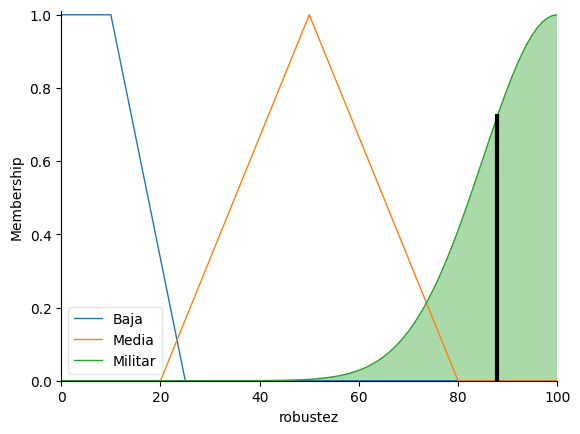

In [9]:
# ============================================================
# REQUERIMIENTO: Importar las bibliotecas necesarias para implementar
# un sistema de lógica difusa usando Scikit-Fuzzy.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl  # Módulo para definir variables lingüísticas, funciones de pertenencia, reglas e inferencia difusa


# ============================================================
# REQUERIMIENTO: Definir el universo del discurso para cada variable difusa.
# - Recursos: porcentaje entre 0 y 100.
# - Sensibilidad: escala entre 0 y 10.
# - Robustez: porcentaje entre 0 y 100.
# ============================================================

Porcentaje_recursos = np.arange(0, 101, 1)
Porcetanje_sensibilidad = np.arange(0, 11, 1)
Porentaje_robustez = np.arange(0, 101, 1)


# ============================================================
# REQUERIMIENTO: Definir al menos 3 variables difusas del dominio.
# En este sistema se definen:
# - recursos: variable de entrada / antecedente.
# - sensibilidad: variable de entrada / antecedente.
# - robustez: variable de salida / consecuente.
# ============================================================

recursos = ctrl.Antecedent(Porcentaje_recursos, 'recursos')
sensibilidad = ctrl.Antecedent(Porcetanje_sensibilidad, 'sensibilidad')
robustez = ctrl.Consequent(Porentaje_robustez, 'robustez')


# ============================================================
# REQUERIMIENTO: Implementar un proceso de defuzzificación justificado.
# Se selecciona el método del centroide porque calcula un valor numérico
# representativo considerando toda el área del conjunto difuso de salida.
# ============================================================

robustez.defuzzify_method = 'centroid'


# ============================================================
# REQUERIMIENTO: Para la variable difusa "recursos", definir mínimo
# 3 valores difusos y asociarles funciones de pertenencia.
#
# También se cumple el requisito de incluir distintos tipos de funciones:
# - Bajo: función trapezoidal.
# - Medio: función triangular.
# - Alto: función Gaussiana.
# ============================================================

Bajo = fuzz.trapmf(recursos.universe, [0, 0, 25, 50])
Medio = fuzz.trimf(recursos.universe, [25, 50, 75])
Alto = fuzz.gaussmf(recursos.universe, 100, 25)


# ============================================================
# REQUERIMIENTO: Para la variable difusa "sensibilidad", definir mínimo
# 3 valores difusos y asociarles funciones de pertenencia.
#
# También se vuelve a evidenciar el uso de:
# - Pública: función trapezoidal.
# - Confidencial: función triangular.
# - Secreta: función Gaussiana.
# ============================================================

Publica = fuzz.trapmf(sensibilidad.universe, [0, 0, 2, 4])
Confidencial = fuzz.trimf(sensibilidad.universe, [2, 4, 6])
Secreta = fuzz.gaussmf(sensibilidad.universe, 8, 2.5)


# ============================================================
# REQUERIMIENTO: Para la variable difusa de salida "robustez",
# definir mínimo 3 valores difusos y asociarles funciones de pertenencia.
#
# Se definen:
# - Baja: función trapezoidal.
# - Media: función triangular.
# - Militar: función Gaussiana.
# ============================================================

Baja = fuzz.trapmf(Porentaje_robustez, [0, 0, 10, 25])
Media = fuzz.trimf(Porentaje_robustez, [20, 50, 80])
Militar = fuzz.gaussmf(Porentaje_robustez, 100, 15)


# ============================================================
# REQUERIMIENTO: Hacer uso de dos casos de modificadores difusos.
#
# Modificador 1:
# - "Muy secreta" se obtiene elevando al cuadrado la pertenencia de "Secreta".
# - Fórmula aplicada: μ_muy A(x) = [μ_A(x)]²
#
# Modificador 2:
# - "Ligeramente bajo" se obtiene aplicando raíz cuadrada a la pertenencia de "Bajo".
# - Fórmula aplicada: μ_ligeramente A(x) = sqrt(μ_A(x))
# ============================================================

MUy_secreta = np.power(Secreta, 2)
Ligeramente_bajo = np.sqrt(Bajo)


# ============================================================
# REQUERIMIENTO: Registrar los valores lingüísticos y sus funciones de
# pertenencia dentro de cada variable difusa del sistema de control.
#
# Esto permite que las etiquetas puedan ser usadas posteriormente
# en las reglas difusas.
# ============================================================

recursos['Bajo'] = Bajo
recursos['Medio'] = Medio
recursos['Alto'] = Alto
recursos['Ligeramente_bajo'] = Ligeramente_bajo

sensibilidad['Publica'] = Publica
sensibilidad['Confidencial'] = Confidencial
sensibilidad['Secreta'] = Secreta
sensibilidad['Muy_secreta'] = MUy_secreta

robustez['Baja'] = Baja
robustez['Media'] = Media
robustez['Militar'] = Militar


# ============================================================
# REQUERIMIENTO: Definir al menos 9 reglas difusas.
#
# Además, las reglas deben incluir los operadores:
# - Intersección / AND: operador &
# - Complemento / NOT: operador ~
# - Unión / OR: operador |
#
# Las reglas 1 a 7 usan principalmente AND.
# La regla 6 incluye complemento o negación.
# La regla 9 incluye unión u OR.
# ============================================================

# Regla con operador AND:
# Si los recursos son altos Y la sensibilidad es pública,
# entonces la robustez requerida es baja.
Regla1 = ctrl.Rule(recursos['Alto'] & sensibilidad['Publica'], robustez['Baja'])

# Regla con operador AND:
# Si los recursos son medios Y la sensibilidad es pública,
# entonces la robustez requerida es media.
Regla2 = ctrl.Rule(recursos['Medio'] & sensibilidad['Publica'], robustez['Media'])

# Regla con operador AND:
# Si los recursos son bajos Y la sensibilidad es pública,
# entonces la robustez requerida es media.
Regla3 = ctrl.Rule(recursos['Bajo'] & sensibilidad['Publica'], robustez['Media'])

# Regla con operador AND:
# Si los recursos son medios Y la sensibilidad es confidencial,
# entonces la robustez requerida es media.
Regla4 = ctrl.Rule(recursos['Medio'] & sensibilidad['Confidencial'], robustez['Media'])

# Regla con operador AND:
# Si los recursos son bajos Y la sensibilidad es confidencial,
# entonces la robustez requerida es militar.
Regla5 = ctrl.Rule(recursos['Bajo'] & sensibilidad['Confidencial'], robustez['Militar'])

# Regla con operador AND y complemento / negación:
# Si la sensibilidad es secreta Y los recursos NO son altos,
# entonces la robustez requerida es militar.
Regla6 = ctrl.Rule(sensibilidad['Secreta'] & ~recursos['Alto'], robustez['Militar'])

# Regla con operador AND:
# Si los recursos son altos Y la sensibilidad es secreta,
# entonces la robustez requerida es media.
Regla7 = ctrl.Rule(recursos['Alto'] & sensibilidad['Secreta'], robustez['Media'])

# Regla basada en modificador difuso:
# Si la sensibilidad es muy secreta,
# entonces la robustez requerida es militar.
Regla8 = ctrl.Rule(sensibilidad['Muy_secreta'], robustez['Militar'])

# Regla con operador OR y uso de modificadores difusos:
# Si los recursos son ligeramente bajos O la sensibilidad es muy secreta,
# entonces la robustez requerida es militar.
Regla9 = ctrl.Rule(recursos['Ligeramente_bajo'] | sensibilidad['Muy_secreta'], robustez['Militar'])


# ============================================================
# REQUERIMIENTO: Construir el sistema de inferencia difusa usando
# las 9 reglas definidas anteriormente.
# ============================================================

sistema_control = ctrl.ControlSystem([
    Regla1,
    Regla2,
    Regla3,
    Regla4,
    Regla5,
    Regla6,
    Regla7,
    Regla8,
    Regla9
])


# ============================================================
# REQUERIMIENTO: Crear una simulación del sistema de control difuso
# para poder ingresar valores concretos y realizar la inferencia.
# ============================================================

simulacion = ctrl.ControlSystemSimulation(sistema_control)


# ============================================================
# REQUERIMIENTO: Asignar valores de entrada al sistema difuso.
#
# Caso de prueba:
# - recursos = 10
# - sensibilidad = 9
#
# Estos valores permiten evaluar el comportamiento del sistema
# y evidenciar la activación de reglas difusas.
# ============================================================

simulacion.input['recursos'] = 10
simulacion.input['sensibilidad'] = 9


# ============================================================
# REQUERIMIENTO: Ejecutar el proceso de inferencia difusa.
#
# En esta etapa Scikit-Fuzzy evalúa las reglas activadas,
# agrega las salidas difusas y aplica posteriormente la defuzzificación.
# ============================================================

simulacion.compute()


# ============================================================
# REQUERIMIENTO: Obtener y mostrar el resultado defuzzificado.
#
# Como se configuró previamente el método "centroid",
# el resultado corresponde al centroide del conjunto difuso de salida.
# ============================================================

resultado_robustez = simulacion.output['robustez']
print(f"La robustez requerida es: {resultado_robustez:.2f}%")


# ============================================================
# REQUERIMIENTO COMPLEMENTARIO: Clasificar el resultado numérico
# obtenido después de la defuzzificación en una etiqueta lingüística.
#
# Esta parte no es obligatoria en el enunciado, pero ayuda a interpretar
# el porcentaje final de robustez.
# ============================================================

def clasificar_robustez(valor):

    if valor < 30:
        return "Baja"
    elif valor < 70:
        return "Media"
    else:
        return "Militar"


# ============================================================
# REQUERIMIENTO COMPLEMENTARIO: Mostrar la clasificación lingüística
# del resultado obtenido.
# ============================================================

nivel_robustez = clasificar_robustez(resultado_robustez)

print("Nivel de robustez clasificado:", nivel_robustez)


# ============================================================
# REQUERIMIENTO COMPLEMENTARIO: Visualizar gráficamente la salida
# del sistema difuso después de la simulación.
#
# Esto permite evidenciar el conjunto difuso de salida y el valor
# defuzzificado obtenido mediante el método del centroide.
# ============================================================

robustez.view(sim=simulacion)

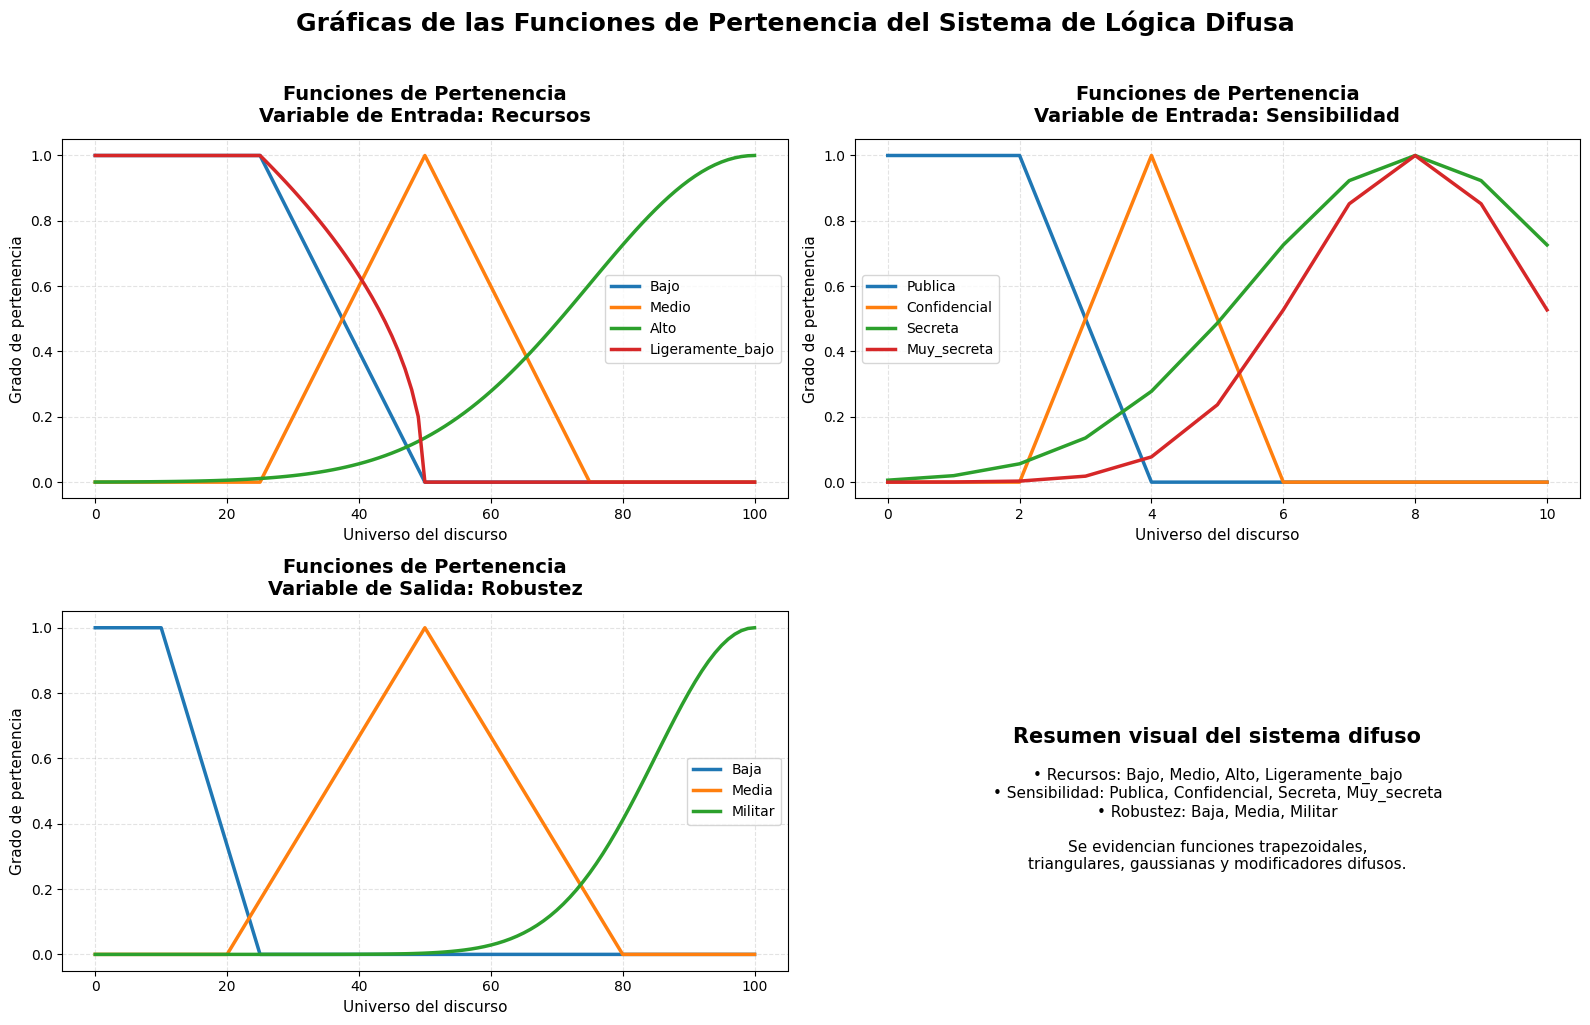

In [10]:
# ============================================================
# Gráficas de funciones de pertenencia utilizadas
# en el componente de lógica difusa.
# Se presentan en formato grid para reducir ruido visual y hacer
# más amigable la lectura del Notebook.
# ============================================================

import matplotlib.pyplot as plt

# Lista de variables difusas a graficar
variables_difusas = [
    (recursos, "Funciones de Pertenencia\nVariable de Entrada: Recursos"),
    (sensibilidad, "Funciones de Pertenencia\nVariable de Entrada: Sensibilidad"),
    (robustez, "Funciones de Pertenencia\nVariable de Salida: Robustez")
]

# Crear grid de subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

# Graficar cada variable difusa en un subplot
for i, (variable, titulo) in enumerate(variables_difusas):
    ax = axes[i]
    
    for etiqueta in variable.terms:
        ax.plot(
            variable.universe,
            variable[etiqueta].mf,
            linewidth=2.5,
            label=etiqueta
        )
    
    ax.set_title(titulo, fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel("Universo del discurso", fontsize=11)
    ax.set_ylabel("Grado de pertenencia", fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='best', fontsize=10, frameon=True)

# Último espacio del grid: texto explicativo
axes[3].axis('off')
axes[3].text(
    0.5, 0.65,
    "Resumen visual del sistema difuso",
    ha='center', va='center',
    fontsize=15, fontweight='bold'
)
axes[3].text(
    0.5, 0.42,
    "• Recursos: Bajo, Medio, Alto, Ligeramente_bajo\n"
    "• Sensibilidad: Publica, Confidencial, Secreta, Muy_secreta\n"
    "• Robustez: Baja, Media, Militar\n\n"
    "Se evidencian funciones trapezoidales,\n"
    "triangulares, gaussianas y modificadores difusos.",
    ha='center', va='center',
    fontsize=11
)

# Título general de toda la figura
fig.suptitle(
    "Gráficas de las Funciones de Pertenencia del Sistema de Lógica Difusa",
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()